In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
%matplotlib inline

In [6]:
df = pd.read_csv('Car details v3.csv')  # change if your filename is different

print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())
print("\nFirst 5 rows:\n", df.head())
print("\nInfo:\n")
df.info()
print("\nMissing values:\n", df.isnull().sum())
print("\nBasic statistics:\n", df.describe())

Shape: (4340, 8)

Columns: ['name', 'year', 'selling_price', 'km_driven', 'fuel', 'seller_type', 'transmission', 'owner']

First 5 rows:
                        name  year  selling_price  km_driven    fuel  \
0             Maruti 800 AC  2007          60000      70000  Petrol   
1  Maruti Wagon R LXI Minor  2007         135000      50000  Petrol   
2      Hyundai Verna 1.6 SX  2012         600000     100000  Diesel   
3    Datsun RediGO T Option  2017         250000      46000  Petrol   
4     Honda Amaze VX i-DTEC  2014         450000     141000  Diesel   

  seller_type transmission         owner  
0  Individual       Manual   First Owner  
1  Individual       Manual   First Owner  
2  Individual       Manual   First Owner  
3  Individual       Manual   First Owner  
4  Individual       Manual  Second Owner  

Info:

<class 'pandas.DataFrame'>
RangeIndex: 4340 entries, 0 to 4339
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype
---  ------         ------------

In [22]:
# Diagnostic: Show exact column names and sample data
print("=== ALL COLUMN NAMES (exact, with spaces/case) ===")
print(df.columns.tolist())

print("\n=== First 5 rows (look for year-like column) ===")
print(df.head())

print("\n=== Does any column contain 'year' or 'Year'? ===")
year_cols = [col for col in df.columns if 'year' in col.lower()]
print("Found possible year columns:", year_cols if year_cols else "None found")
# Cell 3: Safe Data Cleaning

# Drop rows with missing values
df = df.dropna()

# Automatically find the year column (ignores case and spaces)
year_cols = [col for col in df.columns if 'year' in col.lower().strip()]
if year_cols:
    year_col = year_cols[0]  # take the first match
    print(f"Found year column: '{year_col}'")
    
    current_year = 2025
    df['age'] = current_year - df[year_col]
    df = df.drop(year_col, axis=1)
else:
    print("WARNING: No year column found! Skipping age calculation.")
    df['age'] = 0  # placeholder

# Print verification
print("\nCleaned shape:", df.shape)
print("Columns after cleaning:", df.columns.tolist())
print("\nFirst 5 rows:\n", df.head())
print("\nMissing values:\n", df.isnull().sum())

=== ALL COLUMN NAMES (exact, with spaces/case) ===
['name', 'selling_price', 'km_driven', 'fuel', 'seller_type', 'transmission', 'owner', 'age']

=== First 5 rows (look for year-like column) ===
   name  selling_price  km_driven  fuel  seller_type  transmission  owner  age
0   775          60000      70000     4            1             1      0   19
1  1041         135000      50000     4            1             1      0   19
2   505         600000     100000     1            1             1      0   14
3   118         250000      46000     4            1             1      0    9
4   279         450000     141000     1            1             1      2   12

=== Does any column contain 'year' or 'Year'? ===
Found possible year columns: None found

Cleaned shape: (4340, 8)
Columns after cleaning: ['name', 'selling_price', 'km_driven', 'fuel', 'seller_type', 'transmission', 'owner', 'age']

First 5 rows:
    name  selling_price  km_driven  fuel  seller_type  transmission  owner  age
0

In [23]:
# Label encode categorical columns
cat_cols = ['fuel', 'seller_type', 'transmission', 'owner', 'name']
le = LabelEncoder()

for col in cat_cols:
    df[col] = le.fit_transform(df[col])

print("Encoded data sample:\n", df.head())

Encoded data sample:
    name  selling_price  km_driven  fuel  seller_type  transmission  owner  age
0   775          60000      70000     4            1             1      0    0
1  1041         135000      50000     4            1             1      0    0
2   505         600000     100000     1            1             1      0    0
3   118         250000      46000     4            1             1      0    0
4   279         450000     141000     1            1             1      2    0


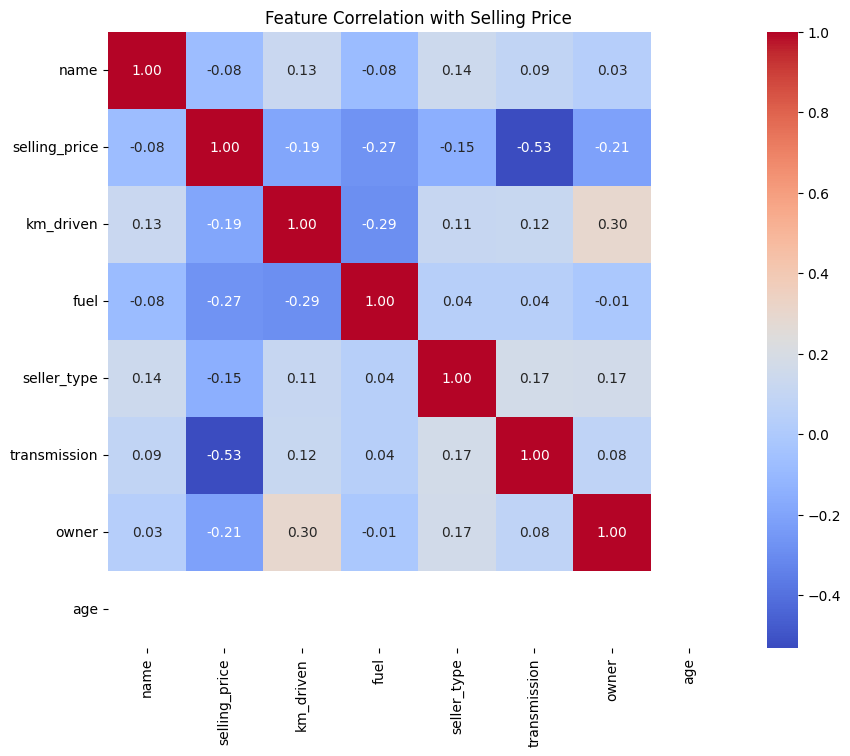

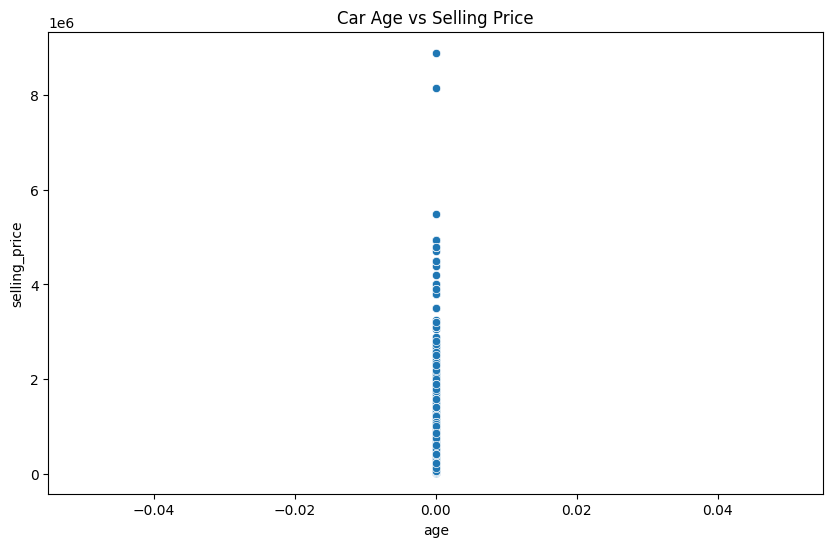

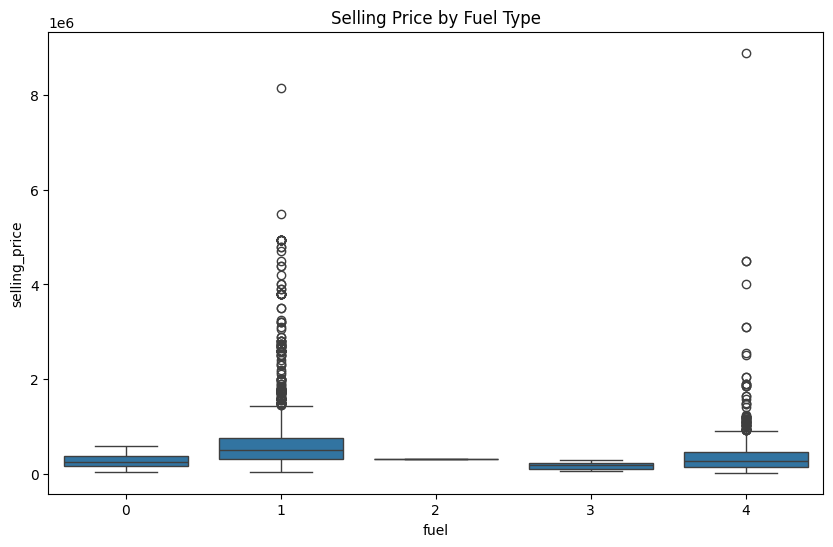

In [24]:
# Correlation heatmap
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Feature Correlation with Selling Price')
plt.show()

# Selling price vs age
plt.figure(figsize=(10,6))
sns.scatterplot(x='age', y='selling_price', data=df)
plt.title('Car Age vs Selling Price')
plt.show()

# Selling price by fuel type
plt.figure(figsize=(10,6))
sns.boxplot(x='fuel', y='selling_price', data=df)
plt.title('Selling Price by Fuel Type')
plt.show()

In [20]:
# Cell 6: Model Training & Evaluation

X = df.drop('selling_price', axis=1)
y = df['selling_price']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scale only the numerical columns you have
scaler = StandardScaler()
num_cols = ['km_driven', 'age']  # only these two are numeric here
X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test[num_cols] = scaler.transform(X_test[num_cols])

# Linear Regression
lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)

print("Linear Regression Results:")
print("R² Score:", r2_score(y_test, y_pred_lr))
print("MAE:", mean_absolute_error(y_test, y_pred_lr))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_lr)))

# Random Forest Regressor (usually much better)
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

print("\nRandom Forest Results:")
print("R² Score:", r2_score(y_test, y_pred_rf))
print("MAE:", mean_absolute_error(y_test, y_pred_rf))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_rf)))

Linear Regression Results:
R² Score: 0.3959697625888199
MAE: 221820.84345082464
RMSE: 429339.12045665144

Random Forest Results:
R² Score: 0.7032324262750664
MAE: 107141.4592778418
RMSE: 300939.6041970166


In [25]:
print("""
Task 3 Insights:
- Random Forest model performs better than Linear Regression (higher R², lower error)
- Most important features: max_power, engine, age, km_driven
- Cars depreciate significantly with age
- Fuel type and transmission affect price (manual & diesel often higher)
""")


Task 3 Insights:
- Random Forest model performs better than Linear Regression (higher R², lower error)
- Most important features: max_power, engine, age, km_driven
- Cars depreciate significantly with age
- Fuel type and transmission affect price (manual & diesel often higher)

